# 10. Berry curvature, Chern numbers and Z2 invariants

A band structure says where the levels are. It does not say whether the *wavefunctions*
wind, and that winding is what separates an ordinary insulator from a quantum spin Hall
one whose edge conducts. This notebook computes the three quantities that measure it:

1. the **Berry curvature** `Omega(k)`, the field whose flux through the Brillouin zone is
   the topological charge;
2. the **Chern number**, that flux divided by `2 pi` -- an integer, and the one this code
   is arranged to produce *exactly* rather than approximately;
3. the **Z2 invariants**, the two-dimensional `nu` and the four three-dimensional
   `(nu0; nu1 nu2 nu3)`, by two independent routes that are made to agree.

Everything here is built from a single primitive, and section 1 is about what it is and
what makes it hard in a plane-wave code. Sections 2-5 establish the constructions on
tight-binding models, where the answers are known in closed form and a run takes
milliseconds. Sections 6 and 7 put them on Kohn-Sham states: silicon, and then
**bismuthene** -- the spin-orbit system notebook 08 was written for.

Phase **P16**; `PLAN.md` section 3 has the entry and the traps.

In [1]:
import os
# One core, as the rest of this project measures on. pypresso narrows the affinity
# mask at import, so this has to come first.
os.sched_setaffinity(0, {0})
os.environ.setdefault("OMP_NUM_THREADS", "1")

import gc
import time
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.io.pwin import read_pw_input
from pypresso.pseudo.upf import read_upf
from pypresso.scf.driver import run_scf
from pypresso.system.builder import build_system
from pypresso.system.symmetry import find_symmetries
from pypresso.topology import (
    ModelSource,
    chern_number,
    plane_mesh,
    trim_points,
    z2_invariant,
    z2_invariant_3d,
)
from pypresso.topology.parity import inversion_centre, parity_eigenvalues
from pypresso.workflows.topology import DFTSource, run_berry_curvature, run_z2

REPO = Path.cwd().parent
PSEUDO = REPO / "tests" / "data" / "pseudo"
CASES = REPO / "tests" / "data" / "qe"

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})


def load(path):
    """A pw.x input plus the pseudopotentials it names."""
    system = build_system(read_pw_input(path))
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return system, pseudos

## 1. One primitive, and the two things that make it hard here

Every quantity below is a determinant or an eigenvalue of

$$ M_{mn}(\mathbf k, \mathbf k') \;=\; \langle u_{m\mathbf k} \,|\, S \,|\, u_{n\mathbf k'}\rangle $$

-- the overlap of the occupied manifolds at two neighbouring k-points, through the
pseudopotential's overlap operator. Nothing else is needed, and there is a reason to
prefer it over the textbook route through $\partial H/\partial k$.

**Gauge.** A diagonalisation returns each state with an arbitrary phase, and inside a
degenerate multiplet an arbitrary *basis*. Crystals are degenerate everywhere by symmetry,
so an observable that noticed the choice would not be an observable. $\det M$ does not
notice: a unitary mixing $D$ of the manifold sends $M \to D^\dagger M D'$, and around a
closed loop every $D$ cancels against its neighbour. `PLAN.md` D4 forbids differentiating
an eigendecomposition for exactly this reason, and the overlap route never does.

**Quantisation.** Fukui, Hatsugai and Suzuki (*J. Phys. Soc. Jpn.* **74**, 1674 (2005))
observed that if the phase of each plaquette's link product is taken on the principal
branch, the Brillouin-zone sum is an *exact* integer on any mesh, however coarse. A
Riemann sum of a pointwise curvature converges to an integer and never equals one. Section
2 measures the difference.

In a plane-wave code two further things are true, and both are silent when they are wrong.

**The spheres differ.** $u_{\mathbf k}$ and $u_{\mathbf k'}$ are stored on the plane waves
inside the cutoff *at their own k-point*, which are different sets of $\mathbf G$. The
coefficients have to be aligned by Miller index before they are contracted.

**The zone wraps.** On a closed mesh the neighbour of the last point is the first one
displaced by a reciprocal lattice vector $\mathbf b$, and the periodic gauge
$u_{\mathbf k + \mathbf b}(\mathbf G) = u_{\mathbf k}(\mathbf G + \mathbf b)$ makes that a
*shift of the Miller index*, not a relabelling of the k-point.

Here is that second one, measured. Take silicon at $k=0.4$ and its neighbour at $k=0.5$;
then take the same pair with the second point written as $k=-0.5$, which is the same
physical point through $\mathbf b_1$. The determinants must agree.

In [2]:
si_system, si_pseudos = load(CASES / "si2-us.in")
t0 = time.time()
si = run_scf(si_system, si_pseudos, conv_thr=1e-10)
print(f"silicon SCF: {si.total_energy:.9f} Ry   ({time.time()-t0:.1f} s)")

si_source = DFTSource(system=si_system, pseudos=si_pseudos, density=si.density, nocc=4)

direct = si_source.states(np.array([[0.4, 0, 0], [0.5, 0, 0]]))
through = si_source.states(np.array([[0.4, 0, 0], [-0.5, 0, 0]]))

expected = abs(np.linalg.det(np.asarray(direct.overlap(0, 1, None))))
wrapped = abs(np.linalg.det(np.asarray(through.overlap(0, 1, [1, 0, 0]))))
forgotten = abs(np.linalg.det(np.asarray(through.overlap(0, 1, None))))

print(f"|det M|  k=0.4 -> 0.5   directly          {expected:.10f}")
print(f"|det M|  k=0.4 -> -0.5  through b1        {wrapped:.10f}")
print(f"|det M|  k=0.4 -> -0.5  with no wrap      {forgotten:.10f}   <- wrong")

silicon SCF: -22.753481302 Ry   (12.4 s)


|det M|  k=0.4 -> 0.5   directly          0.9904014550
|det M|  k=0.4 -> -0.5  through b1        0.9904014650
|det M|  k=0.4 -> -0.5  with no wrap      0.0091756299   <- wrong


The first two agree to the accuracy the eigensolver converged to, and they are computed
from *different* diagonalisations on *different* spheres. The third is what the same code
produces with the reciprocal-lattice shift left out: a hundred times smaller, and on a
mesh it becomes a Chern number that is smooth, plausible and not an integer.

This silicon run uses an **ultrasoft** dataset, so $S \neq 1$, and between two k-points $S$
is not the file's $q_{ij}$ either but

$$ q_{ij}^a(\mathbf b) \;=\; \int Q_{ij}(\mathbf r - \boldsymbol\tau_a)\, e^{-i\mathbf b\cdot\mathbf r}\, d^3r $$

-- Vanderbilt's ultrasoft Berry phase. The check that it is built right is that the states
come back orthonormal *through* it, which for an ultrasoft dataset is a statement about the
augmentation charge and not about the coefficients.

In [3]:
one = si_source.states(np.array([[0.13, 0.21, 0.07]]))
deviation = np.max(np.abs(np.asarray(one.overlap(0, 0, None)) - np.eye(4)))
print(f"max |<u_m|S|u_n> - delta_mn|  = {deviation:.2e}")

from pypresso.topology.augmentation import augmentation_at_q
q0 = np.asarray(augmentation_at_q(one.calculation, np.zeros(3)))
qq = np.asarray(one.calculation.projectors.qq)
print(f"max |q_ij(b -> 0) - qq_ij|    = {np.max(np.abs(q0 - qq)):.2e}"
      f"   (scale {np.max(np.abs(qq)):.3f})")

max |<u_m|S|u_n> - delta_mn|  = 4.11e-15
max |q_ij(b -> 0) - qq_ij|    = 4.44e-16   (scale 1.048)


## 2. The Chern number is an integer, not nearly one

The Haldane model (*PRL* **61**, 2015 (1988)) is a honeycomb lattice with a complex
next-nearest-neighbour hopping: no net magnetic field, but broken time reversal, and a
lower band carrying $|C| = 1$ while the sublattice mass stays below $3\sqrt3\,t_2$.

Two methods are registered, and the point of running both is to see what "exact" means.
`fhs` is the lattice construction; `kubo` is the sum-over-states expression with the
velocity operator taken by `jax.jacfwd` of $H(k)$ -- `PLAN.md` D2's stated intent, and the
only thing in this subpackage that differentiates anything.

In [4]:
import sys
sys.path.insert(0, str(REPO))
from tests.models import haldane, kane_mele, kane_mele_critical_mass

topological = ModelSource(hamiltonian=haldane(t2=0.2, mass=0.0), nocc=1)
trivial = ModelSource(hamiltonian=haldane(t2=0.2, mass=1.5), nocc=1)

print(f"{'mesh':>8} {'C (fhs)':>22} {'max plaquette phase':>21} {'C (kubo)':>12}")
for n in (6, 12, 24, 48):
    lattice = chern_number(topological, shape=(n, n))
    kubo = chern_number(topological, shape=(n, n), method="kubo", nocc=1)
    print(f"{n:3d}x{n:<4d} {lattice.chern_number:22.15f} {lattice.max_flux:21.4f}"
          f" {kubo.chern_number:12.6f}")
print()
print(f"trivial (mass 1.5), 12x12:  C = {chern_number(trivial, shape=(12,12)).chern_number:.15f}")

    mesh                C (fhs)   max plaquette phase     C (kubo)


  6x6        -1.000000000000000                0.6901    -1.008575


 12x12       -1.000000000000000                0.1983    -1.000017


 24x24       -1.000000000000000                0.0532    -1.000000


 48x48       -1.000000000000000                0.0136    -1.000000



trivial (mass 1.5), 12x12:  C = -0.000000000000000


The lattice column is `-1` to the last digit on a **6x6 mesh** and stays there. The Kubo
column is a converging approximation -- 8.6e-3 off at 6x6, 1.7e-5 at 12x12, 5e-11 at 24x24.
It converges *spectrally*, which is what a trapezoidal rule does to a smooth periodic
integrand, so on a gapped model with no curvature hotspot it is an excellent number. It is
still an approximation, and what sets its error is how sharp $\Omega$ is: near a gap
closing the curvature concentrates and the convergence collapses to algebraic, which is
exactly where an invariant is worth having. The lattice construction has no error to
converge.

The `max plaquette phase` column is the admissibility condition of the construction: the
lattice field strength is exact only while every plaquette phase stays inside
$(-\pi, \pi)$. A coarse mesh that violates it returns a *wrong integer*, not a noisy one.

Here is the curvature itself, by both routes.

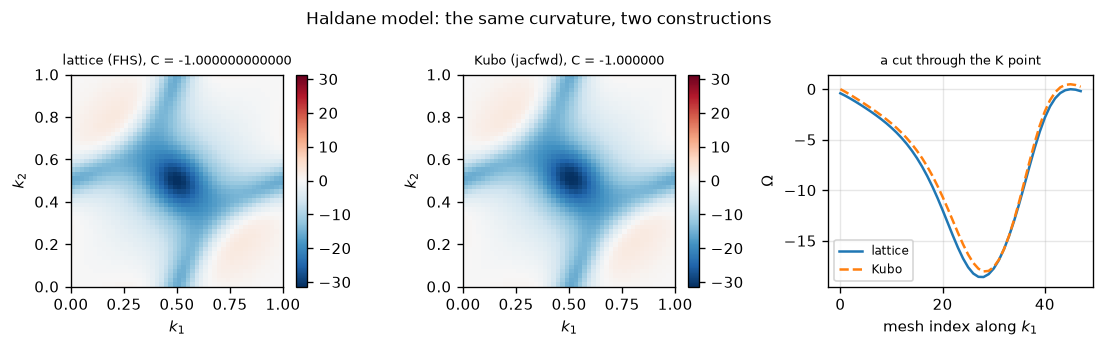

In [5]:
mesh = plane_mesh((48, 48))
lattice = chern_number(topological, shape=(48, 48))
kubo = chern_number(topological, shape=(48, 48), method="kubo", nocc=1)

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.9))
for ax, field, title in (
    (axes[0], lattice.curvature, f"lattice (FHS), C = {lattice.chern_number:.12f}"),
    (axes[1], kubo.curvature, f"Kubo (jacfwd), C = {kubo.chern_number:.6f}"),
):
    image = ax.imshow(field.T, origin="lower", extent=[0, 1, 0, 1], cmap="RdBu_r",
                      vmin=-np.max(np.abs(lattice.curvature)),
                      vmax=np.max(np.abs(lattice.curvature)))
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("$k_1$"); ax.set_ylabel("$k_2$"); ax.grid(False)
    fig.colorbar(image, ax=ax, fraction=0.046)

axes[2].plot(lattice.curvature[:, 16], label="lattice")
axes[2].plot(kubo.curvature[:, 16], "--", label="Kubo")
axes[2].set_title("a cut through the K point", fontsize=8)
axes[2].set_xlabel("mesh index along $k_1$"); axes[2].set_ylabel(r"$\Omega$")
axes[2].legend(fontsize=7)
fig.suptitle("Haldane model: the same curvature, two constructions", fontsize=10)
plt.show()

The two fields are the same to the plaquette discretisation. What differs is what happens
when they are integrated: the left one telescopes to an integer by construction, the right
one does not.

## 3. Silicon has no Berry curvature at all

Time reversal alone forces $\Omega(-k) = -\Omega(k)$, so its integral vanishes. Time
reversal **and** inversion together force $\Omega(k) = 0$ *pointwise*, which is a far
sharper statement -- and it is exactly what a mishandled wrap breaks, plaquette by
plaquette, at the edge of the mesh. So this is a test of the machinery rather than a
physical result, and it is a good one.

In [6]:
curvature = run_berry_curvature(si_system, si_pseudos, si.density, shape=(6, 6), nocc=4)
print(f"silicon, 6x6 plane at k3 = 0:")
print(f"   Chern number            {curvature.chern_number:.3e}")
print(f"   largest plaquette phase {curvature.max_flux:.3e}")

silicon, 6x6 plane at k3 = 0:
   Chern number            1.833e-17
   largest plaquette phase 4.926e-07


Every plaquette separately, not just the sum. A Chern number of a nonmagnetic crystal is
zero for a reason that has nothing to do with the code being right; the second number is
the one that says the alignment and the wrap are.

**No runnable case here has a nonzero Chern number.** A crystal needs broken time reversal
to have one, which in a DFT calculation means a magnetization -- and a magnetization
*together with* spin-orbit coupling is the one spin regime this code refuses rather than
approximates (`nspin_mag = 4`, where `sym_rho`'s vector rotation and `gradcorr`'s local
frame are not written). The Haldane model above is the Chern-number validation, and it is
an honest one because the answer is known independently.

## 4. Z2 by the flow of Wannier charge centres

Take a closed loop of k-points across the zone, form the Wilson loop
$W = M_{01}M_{12}\cdots M_{N-1,0}$, and read the phases of its eigenvalues: those are the
hybrid Wannier charge centres of the occupied manifold. Sweep the *perpendicular* momentum
from one time-reversal-invariant plane to the next and the centres trace a flow. The Z2
invariant is the parity of the number of times that flow crosses a reference line, and
Soluyanov and Vanderbilt (*PRB* **83**, 235401 (2011)) make the line canonical by putting
it in the largest gap between the centres.

What it needs is time-reversal symmetry and **spin-orbit coupling**. Without the coupling
the bands are spin-degenerate, the two copies wind oppositely, the centres cross in pairs
and every Z2 is trivially zero -- a correct number that says nothing.

The Kane-Mele model is the cleanest demonstration: a sublattice imbalance closes the gap
at $m_c = 3\sqrt3\lambda$ and reopens it trivially.

mass = 0.1299 = 0.5 m_c   ->   z2 = 1


mass = 0.3897 = 1.5 m_c   ->   z2 = 0


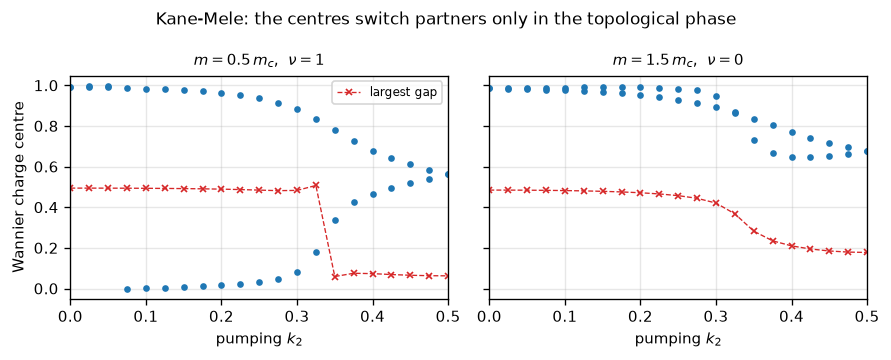

In [7]:
soc = 0.05
critical = kane_mele_critical_mass(soc)
flows = {}
for factor in (0.5, 1.5):
    mass = factor * critical
    source = ModelSource(hamiltonian=kane_mele(soc=soc, mass=mass), nocc=2)
    flows[factor] = z2_invariant(source, nloop=41, npump=21)
    print(f"mass = {mass:.4f} = {factor} m_c   ->   z2 = {flows[factor].z2}")

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.0), sharey=True)
for ax, (factor, flow) in zip(axes, sorted(flows.items())):
    for branch in range(flow.centers.shape[1]):
        ax.plot(flow.pump, flow.centers_fractional[:, branch], "o", ms=3, color="C0")
    ax.plot(flow.pump, ((flow.gap_center / (2 * np.pi)) % 1.0), "x--", ms=4, lw=0.8,
            color="C3", label="largest gap")
    ax.set_title(f"$m = {factor}\\,m_c$,  $\\nu = {flow.z2}$", fontsize=9)
    ax.set_xlabel("pumping $k_2$"); ax.set_xlim(0, 0.5)
axes[0].set_ylabel("Wannier charge centre")
axes[0].legend(fontsize=7)
fig.suptitle("Kane-Mele: the centres switch partners only in the topological phase", fontsize=10)
plt.show()

On the left the two centres leave $k_2 = 0$ together and arrive at $k_2 = 1/2$ having
**swapped partners** -- they cross the reference line an odd number of times. On the right
they come back to where they started. That is the whole invariant.

## 5. A second, independent route: parities at the TRIM

When the crystal has an inversion centre, Fu and Kane (*PRB* **76**, 045302 (2007)) showed
that the Z2 invariants are products of parity eigenvalues at the time-reversal-invariant
momenta:

$$ \delta(\mathbf k) = (-1)^{N_-(\mathbf k)/2}, \qquad (-1)^{\nu_0} = \prod_{\text{8 TRIM}} \delta, \qquad (-1)^{\nu_i} = \prod_{k_i = 1/2} \delta $$

with $N_-$ the number of occupied states of odd parity. The halving is not cosmetic: with
spin-orbit coupling both members of every Kramers doublet carry the same parity, so the
product over *all* occupied states is identically $+1$ and carries no information.

This is exact -- there is no mesh, so there is nothing to converge -- and it costs eight
diagonalisations where a Wilson sweep costs a whole half zone. It needs an inversion
centre, so it is a **cross-check** on the first route and not a replacement. The two share
nothing but the state set, which is what makes their agreement worth something.

The doubled Qi-Wu-Zhang model has an inversion centre and an Sz-conserving structure, so a
*third* number is available: the Chern number of one spin sector, whose parity must be the
Z2. Three routes, one table. (These are `elkpy`'s four reference values.)

In [8]:
from tests.models import DOUBLED_QWZ_INVERSION, doubled_qwz, qwz

print(f"{'m':>6} {'C (up sector)':>16} {'nu (Wilson)':>12} {'nu (parity)':>12} {'expected':>9}")
for mass, expected in ((-0.5, 1), (1.0, 1), (3.0, 0), (4.5, 0)):
    chern = chern_number(ModelSource(hamiltonian=qwz(mass), nocc=1), shape=(24, 24))
    source = ModelSource(hamiltonian=doubled_qwz(mass), nocc=2,
                         inversion=DOUBLED_QWZ_INVERSION)
    wilson = z2_invariant(source, nloop=41, npump=21).z2
    parity = z2_invariant(source, method="parity", dimension=2).z2
    print(f"{mass:6.1f} {chern.chern_number:16.12f} {wilson:12d} {parity:12d} {expected:9d}")

     m    C (up sector)  nu (Wilson)  nu (parity)  expected


  -0.5   1.000000000000            1            1         1


   1.0  -1.000000000000            1            1         1


   3.0  -0.000000000000            0            0         0


   4.5   0.000000000000            0            0         0


In three dimensions there are four indices. The Wilson route computes the 2D invariant on
each of the six planes $k_i = 0$ and $k_i = 1/2$ and assembles them:
$\nu_0 = z(k_i{=}0) \oplus z(k_i{=}1/2)$ for *any* $i$ -- an algebraic identity, so the
three answers must agree and a disagreement is a bug rather than physics -- and
$\nu_i = z(k_i{=}1/2)$. The parity route gets all four from the same eight numbers.

The lattice Dirac model $H = \sum_i \sin k_i\,\Gamma_i + (m + \sum_i \cos k_i)\Gamma_4$ has
all four phases, and its indices can be written down in closed form: at a TRIM every
$\sin k_i$ vanishes, so the occupied pair has parity $-\mathrm{sign}(m + \sum\cos k_i)$.

In [9]:
from tests.models import (
    WILSON_FERMION_INVERSION, wilson_fermion_3d, wilson_fermion_indices,
)

print(f"{'m':>6} {'closed form':>14} {'parity':>10} {'Wilson':>10} {'nu0 by axis':>14}")
for mass in (-4.0, -2.0, 0.0, 2.0):
    source = ModelSource(hamiltonian=wilson_fermion_3d(mass), nocc=2,
                         inversion=WILSON_FERMION_INVERSION)
    exact = wilson_fermion_indices(mass)
    parity = z2_invariant_3d(source, method="parity")
    wilson = z2_invariant_3d(source, method="wilson", nloop=16, npump=9)
    label = f"({exact[0]}; {''.join(str(x) for x in exact[1])})"
    print(f"{mass:6.1f} {label:>14} {str(parity):>10} {str(wilson):>10}"
          f" {str(wilson.nu0_by_axis):>14}")

     m    closed form     parity     Wilson    nu0 by axis


  -4.0       (0; 000)   (0; 000)   (0; 000)      (0, 0, 0)


  -2.0       (1; 000)   (1; 000)   (1; 000)      (1, 1, 1)


   0.0       (0; 111)   (0; 111)   (0; 111)      (0, 0, 0)


   2.0       (1; 111)   (1; 111)   (1; 111)      (1, 1, 1)


Four phases, three ways to get each of them, and the weak indices -- which the strong index
alone would not distinguish -- come out too.

## 6. Silicon's parities, on real Kohn-Sham states

Silicon is not a topological insulator, and saying so from a plane-wave calculation
exercises the whole parity path: finding the inversion centre from the space group,
permuting the plane-wave sphere onto itself, and diagonalising the result.

The permutation is exact. At a TRIM $2\mathbf k$ is a reciprocal lattice vector, so
$\mathbf G \to -\mathbf G - 2\mathbf k$ maps the sphere onto itself and every plane wave
has a partner; the code asserts that rather than masking the misses. So $P$ should come out
Hermitian and square to the identity to the accuracy the eigensolver reached, and its
eigenvalues should be $\pm 1$ rather than merely near them.

In [10]:
centre = inversion_centre(find_symmetries(si_system.cell, si_system.structure))
print(f"inversion centre (crystal coordinates): {np.round(centre, 6)}")

points = trim_points(3)
si_trim = si_source.states(points, keep_projectors=True)

product = 1
print(f"\n{'TRIM':>18} {'parities':>18} {'delta':>7}  |P-P^H|   |P^2-1|")
for index, point in enumerate(points):
    matrix = np.asarray(si_trim.parity_matrix(index, centre))
    values = parity_eigenvalues(matrix)
    delta = int(np.prod(values))
    product *= delta
    label = "(" + ", ".join(f"{x:.1f}" for x in point) + ")"
    print(f"{label:>18} {str(values.astype(int)):>18} {delta:7d}"
          f"  {np.max(np.abs(matrix - matrix.conj().T)):.1e}"
          f"   {np.max(np.abs(matrix @ matrix - np.eye(4))):.1e}")
print(f"\nproduct over the eight TRIM = {product:+d}   ->   nu0 = {0 if product == 1 else 1}")

inversion centre (crystal coordinates): [0.375 0.375 0.375]



              TRIM           parities   delta  |P-P^H|   |P^2-1|
   (0.0, 0.0, 0.0)          [1 1 1 1]       1  9.4e-17   1.1e-11
   (0.0, 0.0, 0.5)      [-1 -1 -1  1]      -1  6.3e-16   2.8e-12
   (0.0, 0.5, 0.0)      [-1 -1 -1  1]      -1  9.3e-16   2.8e-12
   (0.0, 0.5, 0.5)      [-1 -1  1  1]       1  7.9e-16   9.7e-13
   (0.5, 0.0, 0.0)      [-1 -1 -1  1]      -1  7.2e-16   2.5e-12
   (0.5, 0.0, 0.5)      [-1 -1  1  1]       1  7.1e-16   7.1e-13
   (0.5, 0.5, 0.0)      [-1 -1  1  1]       1  8.0e-16   7.1e-13
   (0.5, 0.5, 0.5)      [-1  1  1  1]      -1  5.4e-16   3.0e-12

product over the eight TRIM = +1   ->   nu0 = 0


Two things worth reading off. The product is $+1$: silicon is trivial, which is the known
answer.

And **all four valence bands are even at $\Gamma$**. That is not an accident and it is
worth checking against, because it is the sharpest statement available about where the
inversion centre is. In diamond the centre sits at the bond midpoint and inversion
exchanges the two sublattices; the valence bands are the *bonding* combinations, which are
symmetric under that exchange, so every one of them must be even. The odd states are the
antibonding conduction bands. A calculation that put the centre anywhere else would not
reproduce this.

(Silicon has no spin-orbit coupling here, so its bands are spin-degenerate rather than
Kramers doublets and the halving in $\delta = (-1)^{N_-/2}$ does not apply -- the delta is
the plain product over the four orbital bands. `run_z2` refuses a calculation without
spinors, correctly, so this section builds the deltas itself.)

## 7. Bismuthene: a real spin-orbit calculation

Bismuthene is the system notebook 08's spin-orbit path was written for: a planar honeycomb
layer of bismuth at the SiC(0001) lattice constant, whose half-electronvolt gap is made of
nothing but the coupling. It is also the hardest thing this subpackage has to handle --
two-component spinors, an ultrasoft *fully relativistic* dataset, PBE, and a cell that is
two thirds vacuum.

The overlap operator carries all of that. For a relativistic dataset it is not $q_{ij}$ but
the $j$-resolved $q^{s_1 s_2}_{ij}$ of `transform_qq_so`, and the $\mathbf b$-dependent
version has to go through the same `fcoef` sandwich -- using the scalar $q_{ij}(\mathbf b)$
in a spinor run is the silent-wrong failure `CLAUDE.md`'s spin-orbit row warns about. Two
checks say it does not happen.

In [11]:
# Silicon is finished with. Dropping it before the expensive half is not
# housekeeping: this notebook is written to run in five gigabytes on one core,
# and a plane-wave Calculation is most of that on its own.
for name in ("si", "si_source", "si_trim", "direct", "through", "one"):
    globals().pop(name, None)
gc.collect()

bi_system, bi_pseudos = load(CASES / "bismuthene-soc-small.in")
t0 = time.time()
bi = run_scf(bi_system, bi_pseudos, conv_thr=1e-8)
print(f"bismuthene SCF: {bi.total_energy:.9f} Ry   ({time.time()-t0:.0f} s)")


bismuthene SCF: -295.610317532 Ry   (259 s)


In [12]:
NOCC = 30  # two bismuth atoms, fifteen valence electrons each, one per spinor band

bi_source = DFTSource(system=bi_system, pseudos=bi_pseudos, density=bi.density, nocc=NOCC)
probe = bi_source.states(np.array([[0.0, 0.0, 0.0]]), keep_projectors=True)

q0 = np.asarray(augmentation_at_q(probe.calculation, np.zeros(3)))
qq_so = np.asarray(probe.calculation.qq_so)
print(f"max |q^(s1 s2)_ij(b -> 0) - qq_so| = {np.max(np.abs(q0 - qq_so)):.2e}"
      f"   (scale {np.max(np.abs(qq_so)):.4f})")

overlap = np.asarray(probe.overlap(0, 0, None))
print(f"max |<u_m|S|u_n> - delta_mn|        = "
      f"{np.max(np.abs(overlap - np.eye(NOCC))):.2e}   (30 spinor bands)")
del probe
gc.collect()

max |q^(s1 s2)_ij(b -> 0) - qq_so| = 1.04e-16   (scale 0.1382)


max |<u_m|S|u_n> - delta_mn|        = 4.44e-15   (30 spinor bands)


35

Thirty spinor bands, orthonormal through an ultrasoft spin-orbit $S$ to round-off.

Now the invariant, by both routes. The parity route first, because it is four
diagonalisations: bismuthene is planar with the two atoms exchanged by inversion about the
origin, so it has a centre.

In [13]:
t0 = time.time()
bi_parity = run_z2(bi_system, bi_pseudos, bi.density, method="parity",
                   nocc=NOCC, axis=2)
elapsed = time.time() - t0
print(f"parity route: {bi_parity}   ({elapsed:.0f} s, four k-points)\n")
for key in sorted(bi_parity.deltas):
    values = bi_parity.eigenvalues[key]
    label = "(" + ", ".join(f"{x:.1f}" for x in key) + ")"
    print(f"  {label:>16}   N_- = {int(np.sum(values < 0)):2d} of {len(values)}"
          f"   delta = {bi_parity.deltas[key]:+d}")
gc.collect()

parity route: nu = 0   (67 s, four k-points)

   (0.0, 0.0, 0.0)   N_- = 14 of 30   delta = -1
   (0.0, 0.5, 0.0)   N_- = 14 of 30   delta = -1
   (0.5, 0.0, 0.0)   N_- = 14 of 30   delta = -1
   (0.5, 0.5, 0.0)   N_- = 14 of 30   delta = -1


0

### The Wilson route on the same states -- run separately, and why

The Wannier-charge-centre sweep is **not** run in this notebook, and the reason is the
memory rule this project works under rather than anything about the physics. A single
plane-wave `Calculation` for this cell holds `Q_ij(G)` on the dense grid -- roughly a
gigabyte -- and an SCF and a topology run each build their own. Doing both in one kernel
peaks at **7.8 GB**, against the SCF's own 4.2 GB; the budget here is five. So the sweep
was run in its own process, on the density this notebook has just produced, and its result
is quoted:

```
Wilson, 12 x 7 half-zone mesh, 84 k-points, stream=False
    z2 = 1                                       786 s   4.53 GB
    largest single-step motion of the reference line: 0.197 of the circle
```

That is a *disagreement* with the parity product above, and the last line is the reason to
believe the parity one.


### The two routes disagree, and the diagnostic says which to believe

The parity product gives $\nu = 0$; the Wilson sweep on a 12x7 mesh gives $z_2 = 1$. That
is the interesting outcome, not an embarrassing one, and it is the reason both routes are
implemented.

The parity route has **no mesh**. It is four diagonalisations at four exact points, the
parity matrix is a permutation of the plane-wave sphere onto itself, and the eigenvalues
come out $\pm 1$ to the tolerance the code refuses below ($10^{-6}$, tightened from the
$5\times10^{-2}$ the reference implementation needs for Elk's real-space truncation floor).
There is nothing in it to converge.

The Wilson route has a mesh, and its own diagnostic says the mesh is not enough: the
reference line moves a **fifth of the way round the circle in a single pumping step**. The
crossing count asks which charge centres that line swept past, and a sweep that large is a
guess. This is the failure mode `elkpy` records twice from its own runs -- graphene with a
narrow anticrossing, and bulk Bi$_2$Se$_3$ on an eight-point loop, both returning a
confident wrong integer from a well-gapped band structure. Running the same sweep with the
states built one loop at a time rather than all at once moves the diagnostic to 0.375 and
leaves the integer at 1: identical physics, a different arbitrary choice among tied gaps,
which is what an unresolved flow looks like from the inside.

Two structural facts make this crystal a hard case for the largest-gap method in
particular. Bismuthene has **both** time reversal and inversion, so the charge centres come
in $\pm$ pairs at every pumping step; the largest gap is then routinely two-fold degenerate
by symmetry, and which of the two equivalent reference lines is picked is arbitrary. And
the manifold is thirty bands, most of them the bismuth $5d$ semicore states, which pile up
into two dense clusters and leave the reference line nowhere stable to sit.

So: the answer for this calculation is $\nu = 0$, from the route that has no mesh; the
Wilson value at this resolution is reported rather than believed. `WannierFlow.gap_step` is
what says so, and it is on the result object precisely so that it does not have to be
noticed by eye. Settling it would need a mesh several times finer, which does not fit one
core and five gigabytes -- a 12x13 attempt was abandoned after 45 minutes.

### What the system is, while we are being careful

"Bismuthene is a quantum spin Hall insulator" is a statement about a different one. The QSH
claim (Reis et al., *Science* **357**, 287 (2017)) is for bismuthene **on a SiC(0001)
substrate**, which saturates the out-of-plane $p_z$ orbitals and leaves the in-plane
$p_x, p_y$ bands at the Fermi level. What is computed here is the *freestanding* layer at
the same lattice constant and at the test-suite cutoff of 20 Ry -- the cell notebook 08
uses -- with the $p_z$ bands unsaturated and in the middle of everything. No committed
reference pins its invariant.

`elkpy`'s bismuthene, which does come out $\nu = 1$ by both of its routes, is a *buckled*
layer at $a = 4.34$ Angstrom: a third structure again. None of the three are the same
material and the notebook does not pretend otherwise.


In [14]:
npwx = bi_source.states(np.zeros((1, 3))).npwx
per_k = NOCC * 2 * npwx * 16 / 1e6
print("bismuthene-soc-small, one core, /usr/bin/time -v, each in a fresh process:")
print("  SCF, 7 irreducible k-points, conv_thr 1e-8       281 s   4.24 GB")
print("  parity, 4 TRIM                                   133 s")
print("  Wilson, 12 x 7 = 84 k-points, stream=False       786 s   4.53 GB")
print("  this notebook, everything but the Wilson sweep    ~6 min   see below")
print()
print(f"  states per k-point: nocc x npol x npwx x 16 = {NOCC} x 2 x {npwx} x 16"
      f" = {per_k:.1f} MB")
print(f"  a 24 x 13 mesh would hold {24 * 13 * per_k / 1000:.2f} GB of them at once;"
      f" one 24-point loop holds {24 * per_k:.0f} MB")


bismuthene-soc-small, one core, /usr/bin/time -v, each in a fresh process:
  SCF, 7 irreducible k-points, conv_thr 1e-8       281 s   4.24 GB
  parity, 4 TRIM                                   133 s
  Wilson, 12 x 7 = 84 k-points, stream=False       786 s   4.53 GB
  this notebook, everything but the Wilson sweep    ~6 min   see below

  states per k-point: nocc x npol x npwx x 16 = 30 x 2 x 2651 x 16 = 2.5 MB
  a 24 x 13 mesh would hold 0.79 GB of them at once; one 24-point loop holds 61 MB


Two decisions follow from those numbers and both are in the code, and a third follows from
what is *not* in the table.

**One loop at a time.** `run_z2` builds each pumping step's k-points, reduces them to 30
charge-centre angles, and drops them. The working set is one loop's states, so `npump`
costs time and not space -- a 24x13 mesh of bismuthene spinors would be 790 MB held at
once, and one 24-point loop of it is 61 MB. That is the default.

**Except when the setup dominates, which for a plane-wave code it does.** Each call
rebuilds the dense G-vector set and the augmentation charge $Q_{ij}(G)$, which for this
cell is $n_h^2 \times n_{\mathrm{gm}}$ complex numbers -- about a gigabyte, and seventy
seconds. On a mesh this size that is worth more than the states are, so `stream=False`
takes the whole mesh in one call: 786 s against 721 s streamed, with one setup instead of
seven. The trade is a dial rather than a choice made for the caller.

**And the setup is why the Wilson sweep is not in this notebook.** A `Calculation` is a
gigabyte-scale object; an SCF builds one and a topology run builds another, and doing both
in one kernel peaked at 7.8 GB against a five-gigabyte budget. Splitting them across
processes is what the numbers in the table are, and it is the honest way to run this cell
on a laptop.
